## Bias–Variance Study: Understanding Model Complexity

In the previous notebook, we systematically explored how increasing polynomial degree affects model performance on PM2.5 prediction. The results clearly showed a tradeoff: simpler models tend to underfit, while highly complex models overfit the training data and fail to generalize.

This notebook builds on those observations to formally study the **bias–variance tradeoff**, one of the most fundamental concepts in machine learning.

---

### Objective

The goal of this notebook is to understand how model complexity influences:

- **Bias** (error due to overly simple assumptions)
- **Variance** (sensitivity to training data fluctuations)
- **Generalization performance** on unseen data

---

### What We Observed Previously

From the polynomial regression experiments:

- Low-degree models showed high bias and underfitting.
- Mid-degree models achieved the best validation performance.
- High-degree models exhibited extreme overfitting with unstable validation error.

These patterns suggest a clear relationship between model complexity and generalization ability.

---

### What This Notebook Will Do

In this study, we will:

- Revisit the RMSE trends across polynomial degrees
- Identify the optimal complexity point (best generalization)
- Visualize the bias–variance tradeoff more explicitly
- Build intuition for why overfitting occurs in high-degree models
- Prepare the motivation for introducing regularization techniques (Ridge and Lasso)

---

### Key Insight

The central question is not just *which model performs best*, but:

> How does increasing complexity shift error from bias-dominated to variance-dominated regimes?

---

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import learning_curve

In [10]:
from sklearn.model_selection import train_test_split

In [5]:
# Load datasets
train_df = pd.read_csv("../data/processed/train.csv")
val_df   = pd.read_csv("../data/processed/val.csv")
test_df  = pd.read_csv("../data/processed/test.csv")

TARGET = "pm25"
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_val = val_df.drop(columns=[TARGET])
y_val = val_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

In [6]:
degrees = range(1, 13)

results = []

for degree in degrees:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=degree)),
        ("model", LinearRegression())
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

    results.append({
        "degree": degree,
        "train_rmse": train_rmse,
        "val_rmse": val_rmse
    })

results_df = pd.DataFrame(results)
results_df

,degree,train_rmse,val_rmse
0,1,20.395528,1.770704e+01
1,2,17.991911,1.448344e+01
2,3,14.340579,1.341510e+01
3,4,9.311577,1.474627e+01
4,5,5.051550,8.622553e+01
5,6,1.445253,7.161167e+04
6,7,1.414608,3.407229e+04
7,8,1.382693,6.422596e+05
8,9,1.261392,5.231504e+06
9,10,1.250954,2.756744e+06


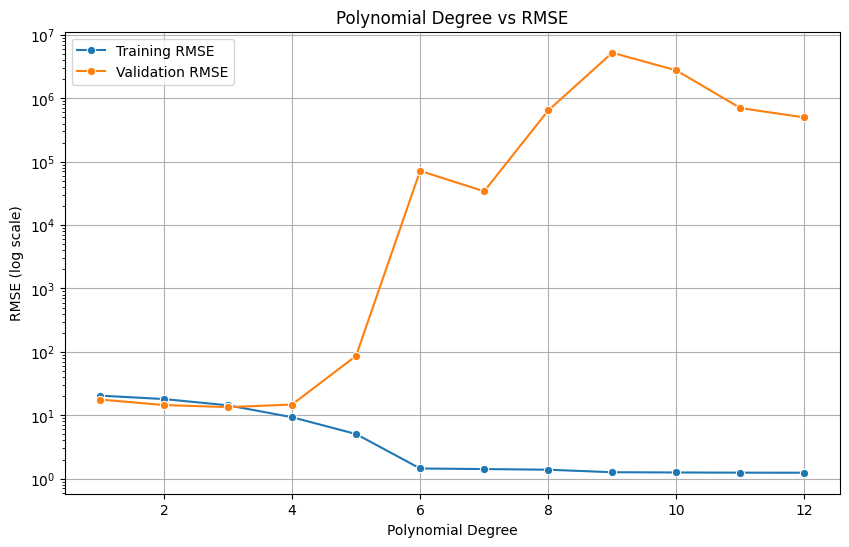

In [8]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=results_df,
    x="degree",
    y="train_rmse",
    marker="o",
    label="Training RMSE"
)

sns.lineplot(
    data=results_df,
    x="degree",
    y="val_rmse",
    marker="o",
    label="Validation RMSE"
)

plt.yscale("log")

plt.title("Polynomial Degree vs RMSE")
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE (log scale)")
plt.grid(True)

plt.savefig("../results/polynomial_degree_rmse_curve_log.png", dpi=300, bbox_inches="tight")
plt.show()

## Observing the Bias-Variance Tradeoff

The graph reveals three distinct learning regimes:

### Underfitting Region (Degree 1-2)
Models are too simple to capture nonlinear relationships.
Both training and validation error remain high.

### Optimal Complexity Region (Degree 3-4)
Validation RMSE reaches its minimum.
The model captures useful structure while still generalizing.

### Overfitting Region (Degree 5+)
Training error continues decreasing,
but validation error increases dramatically.

This divergence indicates high variance:
the model begins memorizing training noise instead of learning general patterns.

In [9]:
# bias > how far your model’s average prediction is from the true value
# High bias → model is consistently wrong in the same way
# Low bias → model is on average close to the truth

# Variance > how much your model’s predictions change if you train it on different data
# High variance → predictions change a lot depending on dataset
# Low variance → predictions are stable and consistent

In [11]:
degree = 10

predictions = []

for seed in range(10):
   X_subtrain, _, y_subtrain, _ = train_test_split(X_train,y_train,test_size=0.3,random_state=seed)
   model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=degree)),
        ("model", LinearRegression())
   ])
   model.fit(X_subtrain, y_subtrain)
   pred = model.predict(X_val)
   predictions.append(pred)
   print(f"{seed} : done")

0 : done
1 : done
2 : done
3 : done
4 : done
5 : done
6 : done
7 : done
8 : done
9 : done


In [12]:
predictions = np.array(predictions)
prediction_variance = predictions.var(axis=0)
print("Average Prediction Variance:", prediction_variance.mean())

Average Prediction Variance: 83827526610458.9


- Your result (8.38 × 10¹³) means the model is highly unstable—small changes in training data cause massive changes in predictions, 
- which is a classic sign of severe overfitting in high-degree polynomial regression.

In [18]:
degree_variance = {}

for degree in [2,3,4,8,12]:

    predictions = []

    for seed in range(10):

        X_subtrain, _, y_subtrain, _ = train_test_split(X_train,y_train,test_size=0.3,random_state=seed)

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("poly", PolynomialFeatures(degree=degree)),
            ("model", LinearRegression())
        ])
        model.fit(X_subtrain, y_subtrain)
        pred = model.predict(X_val)
        predictions.append(pred)
    predictions = np.array(predictions)
    degree_variance[degree] = predictions.var(axis=0).mean()

degree_variance

{2: np.float64(7.633837308216395),
 3: np.float64(34.26008141067411),
 4: np.float64(265.92995576109905),
 8: np.float64(135469070479966.17),
 12: np.float64(10071131920383.12)}

## Prediction Variance Explosion

To quantify model instability, we measured prediction variance
across multiple random training subsets.

The results show a dramatic increase in variance with polynomial degree:

- Degree 2 → stable predictions (variance ~7)
- Degree 4 → moderate instability (~265)
- Degree 8–12 → catastrophic variance (10¹³+)

### Interpretation

This confirms that high-degree polynomial models are not just overfitting,
but becoming numerically unstable estimators.

Small changes in training data produce radically different functions,
indicating extremely high variance.

### Key Insight

Model complexity increases expressiveness,
but beyond a threshold it destroys stability and generalization.

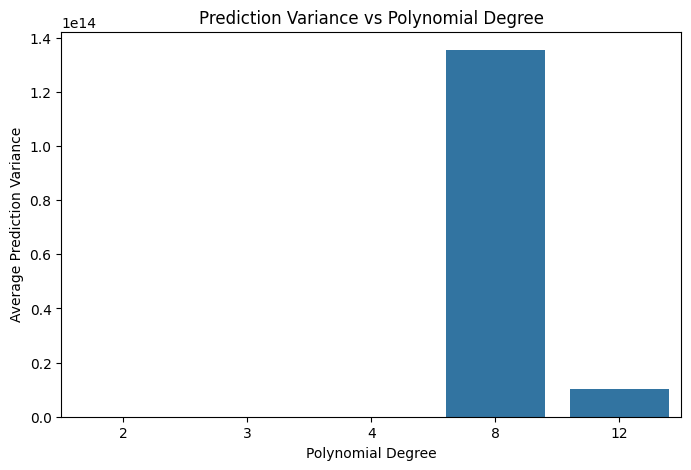

In [19]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=list(degree_variance.keys()),
    y=list(degree_variance.values())
)

plt.title("Prediction Variance vs Polynomial Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("Average Prediction Variance")

plt.show()

In [20]:
from math import comb

n_features = X_train.shape[1]

for degree in range(1, 13):
    poly = PolynomialFeatures(degree=degree)
    poly.fit(X_train)
    print(f"Degree {degree}: "f"{poly.n_output_features_} features")

Degree 1: 7 features
Degree 2: 28 features
Degree 3: 84 features
Degree 4: 210 features
Degree 5: 462 features
Degree 6: 924 features
Degree 7: 1716 features
Degree 8: 3003 features
Degree 9: 5005 features
Degree 10: 8008 features
Degree 11: 12376 features
Degree 12: 18564 features


Higher polynomial degrees dramatically increase feature dimensionality.

This creates:
- sparse high-dimensional spaces,
- unstable coefficient estimation,
- multicollinearity,
- and extreme sensitivity to noise.

These effects collectively increase model variance.

## Conclusion

This study demonstrates that increasing model complexity does not guarantee better generalization.

While high-degree polynomial regression can nearly eliminate training error,
it simultaneously increases variance and destroys validation performance.

The experiments illustrate the fundamental bias-variance tradeoff:

- Simple models suffer from high bias,
- Complex models suffer from high variance,
- Effective models balance both.

These findings motivate the need for regularization methods such as Ridge and Lasso regression,
which will be explored in the next notebook.